## **Parte 2: Estadística Descriptiva**
**Continuación de la Clase Prácitca 2**

Gracias a las cámaras de seguridad de su kiosko, Don Jaime pudo generar un listado con la cantidad de segundos que pasaron sus últimos 100 clientes dentro del local. Ahora, necesita nuestra ayuda para analizar esos datos usando estadística descriptiva.

✨ Generá una lista de 100 valores numéricos que representen los segundos que cada cliente pasó en el local. Tené en cuenta las siguientes condiciones:

1. La mayoría de los valores deberían estar entre 30 y 120 segundos.

2. Algunos valores pueden estar por debajo o por encima para simular casos extremos o outliers.

3. Asegurate de que ningún valor sea menor a 5.

💡 Tip: Podés usar funciones de generación aleatoria, como *np.random.normal*, y aplicar condiciones para corregir valores extremos si es necesario.

Luego, calcular las siguientes medidas:

*   Media.
*   Mediana.
*   Moda.
*   Rango Intercuartil.
*   Varianza.
*   Desviación Estándar.

🕒 Consigna adicional: ¿Cómo se distribuyen los tiempos dentro del kiosko?

media 77.27363814536675
mediana 79.76980227809423
moda 17.22614853313459
varanza 457.94970946128484
desvio 21.39975956550178
irq 38.576873601279274


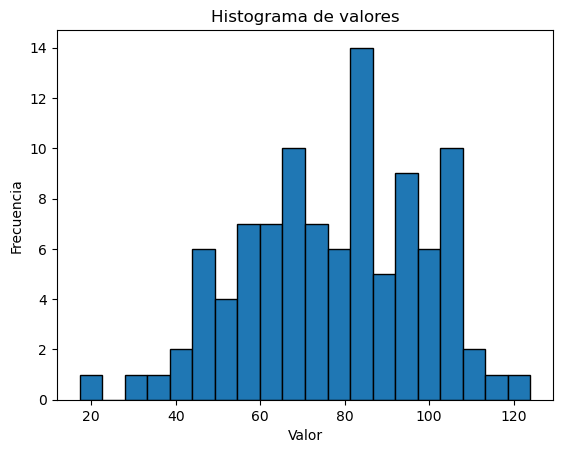

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
rng = np.random.default_rng()
n = 100
Mu =  (30+120)/2
S = (Mu - 30)/2
valores = rng.normal(loc= Mu,scale =S,size=(n))
valores = np.clip(valores,5,np.inf)
valores.sort()
valores = pd.Series(valores)


print('media',valores.mean())
print('mediana' ,valores.median())
print('moda',valores.mode().iat[0])
print('varanza', valores.var())
print('desvio' ,valores.std())
print('irq', valores.quantile(0.75) - valores.quantile(0.2))

plt.hist(valores, bins=20, edgecolor="black")
plt.title("Histograma de valores")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.show()


Don Jaime desea complementar esos datos con la cantidad de productos que el usuario compró. El siguiente listado contiene la cantidad de productos que compró cada uno de los usuarios, ordenados de la misma manera que la lista generada anteriormente.

```
compras = [0, 1, 2, 1, 0, 0, 3, 0, 2, 4, 0, 1, 0, 2, 3, 1, 0, 0, 2, 0,
 4, 1, 0, 0, 3, 2, 1, 1, 2, 3, 0, 5, 0, 2, 2, 1, 4, 0, 2, 0,
 0, 0, 3, 4, 2, 0, 0, 3, 2, 1, 1, 2, 0, 5, 0, 2, 2, 3, 0, 1,
 0, 4, 1, 2, 2, 3, 0, 0, 1, 1, 4, 0, 2, 0, 0, 2, 1, 3, 2, 1,
 2, 0, 0, 1, 0, 5, 1, 2, 3, 1, 0, 4, 1, 2, 0, 0, 0, 6, 0, 0]
```

Calcular las siguientes medidas para la cantidad de productos comprados:

*   Media.
*   Mediana.
*   Moda.
*   Rango Intercuartil.
*   Varianza.
*   Desviación Estándar.

Además, calcular la covarianza y la correlación entre la cantidad de segundos dentro del local y la cantidad de productos comprados.

In [2]:
compras = [0, 1, 2, 1, 0, 0, 3, 0, 2, 4, 0, 1, 0, 2, 3, 1, 0, 0, 2, 0,
 4, 1, 0, 0, 3, 2, 1, 1, 2, 3, 0, 5, 0, 2, 2, 1, 4, 0, 2, 0,
 0, 0, 3, 4, 2, 0, 0, 3, 2, 1, 1, 2, 0, 5, 0, 2, 2, 3, 0, 1,
 0, 4, 1, 2, 2, 3, 0, 0, 1, 1, 4, 0, 2, 0, 0, 2, 1, 3, 2, 1,
 2, 0, 0, 1, 0, 5, 1, 2, 3, 1, 0, 4, 1, 2, 0, 0, 0, 6, 0, 0]

df =  pd.concat([valores, pd.Series(compras)], axis=1)
df.columns = ["Tiempo", "Compras"]
print('media',df["Compras"].mean())
print('mediana' ,df["Compras"].median())
print('moda',df["Compras"].mode().iat[0])
print('varanza', df["Compras"].var())
print('desvio' ,df["Compras"].std())
print('irq', df["Compras"].quantile(0.75) - df["Compras"].quantile(0.2))
print("la covarianza es de ", np.cov(df["Compras"], df["Tiempo"])[0,1])
print("la correlacion es de ", np.corrcoef(df["Compras"], df["Tiempo"])[0,1])



media 1.43
mediana 1.0
moda 0
varanza 2.1869696969696997
desvio 1.478840659763485
irq 2.0
la covarianza es de  1.2489816760056174
la correlacion es de  0.03946624342000811


## **Parte 3: Pandas**

1. Almacenar la información de ambas listas en un DataFrame de pandas.

2. Agregar la siguiente lista como una columna de nombre "id_cliente".

```
cliente_ids = [
    'C005', 'C012', 'C067', 'C044', 'C019', 'C061', 'C002', 'C009', 'C038', 'C041',
    'C036', 'C058', 'C021', 'C003', 'C007', 'C014', 'C020', 'C029', 'C015', 'C055',
    'C046', 'C064', 'C008', 'C011', 'C026', 'C001', 'C050', 'C039', 'C066', 'C035',
    'C027', 'C032', 'C024', 'C030', 'C045', 'C025', 'C022', 'C010', 'C018', 'C054',
    'C016', 'C034', 'C006', 'C028', 'C048', 'C017', 'C059', 'C052', 'C049', 'C056',
    'C037', 'C004', 'C047', 'C013', 'C031', 'C043', 'C033', 'C023', 'C051', 'C057',
    'C042', 'C053', 'C063', 'C062', 'C065', 'C040', 'C060', 'C068', 'C036', 'C002',
    'C026', 'C011', 'C017', 'C028', 'C009', 'C024', 'C001', 'C038', 'C055', 'C014',
    'C045', 'C030', 'C033', 'C046', 'C012', 'C050', 'C016', 'C003', 'C008', 'C035',
    'C025', 'C041', 'C031', 'C019', 'C064', 'C005', 'C021', 'C037', 'C034', 'C049',
    'C063', 'C022', 'C058', 'C018', 'C052', 'C053', 'C056', 'C043', 'C060', 'C015'
]
```



In [3]:
cliente_ids = [
    'C005', 'C012', 'C067', 'C044', 'C019', 'C061', 'C002', 'C009', 'C038', 'C041',
    'C036', 'C058', 'C021', 'C003', 'C007', 'C014', 'C020', 'C029', 'C015', 'C055',
    'C046', 'C064', 'C008', 'C011', 'C026', 'C001', 'C050', 'C039', 'C066', 'C035',
    'C027', 'C032', 'C024', 'C030', 'C045', 'C025', 'C022', 'C010', 'C018', 'C054',
    'C016', 'C034', 'C006', 'C028', 'C048', 'C017', 'C059', 'C052', 'C049', 'C056',
    'C037', 'C004', 'C047', 'C013', 'C031', 'C043', 'C033', 'C023', 'C051', 'C057',
    'C042', 'C053', 'C063', 'C062', 'C065', 'C040', 'C060', 'C068', 'C036', 'C002',
    'C026', 'C011', 'C017', 'C028', 'C009', 'C024', 'C001', 'C038', 'C055', 'C014',
    'C045', 'C030', 'C033', 'C046', 'C012', 'C050', 'C016', 'C003', 'C008', 'C035',
    'C025', 'C041', 'C031', 'C019', 'C064', 'C005', 'C021', 'C037', 'C034', 'C049',
    'C063', 'C022', 'C058', 'C018', 'C052', 'C053', 'C056', 'C043', 'C060', 'C015'
]

df = pd.concat([df, pd.Series(cliente_ids)], axis=1)
df.columns = ["Tiempo", "Compras", "id_cliente"]
df = df[~(df["Tiempo"].isnull())]
df.tail()

,Tiempo,Compras,id_cliente
95,107.070390,0.0,C005
96,111.842681,0.0,C021
97,113.309946,6.0,C037
98,116.734184,0.0,C034
99,123.990256,0.0,C049


3. Descargar el archivo **caracteristicas_clientes.csv** del WebCampus.
4. Importar el archivo usando `pd.read_csv()`.
5. Unificar ambos DataFrames usando `pd.merge()`.

In [4]:
df2 = pd.read_csv(r"C:\Users\Administrador\Downloads\caracteristicas_clientes.csv")

dfFinal = pd.merge(df, df2, left_on="id_cliente", right_on="cliente_id", how="left").drop(columns ="cliente_id")
dfFinal.tail()

,Tiempo,Compras,id_cliente,genero,provincia,edad,km_casa_kiosko,km_trabajo_kiosko,ingreso_mensual,horas_libres_semana,edad_promedio_familia
97,107.070390,0.0,C005,M,Buenos Aires,56.0,NaN,9.8,49855,23,59
98,111.842681,0.0,C021,M,Entre Ríos,57.0,0.3,8.4,32183,39,42
99,113.309946,6.0,C037,F,Córdoba,34.0,5.4,1.5,26893,38,42
100,116.734184,0.0,C034,F,Chaco,26.0,1.2,2.3,391007,24,35
101,123.990256,0.0,C049,M,Tucumán,52.0,1.5,12.2,39830,19,49


6. Realizar un análisis exploratorio de los datos (EDA).

In [5]:
print(f"Tenemos {dfFinal.duplicated().sum()} filas duplicadas")
dfFinal = dfFinal[~ dfFinal.duplicated()]
print(f"Tenemos {dfFinal.duplicated().sum()} filas duplicadas")


Tenemos 2 filas duplicadas
Tenemos 0 filas duplicadas


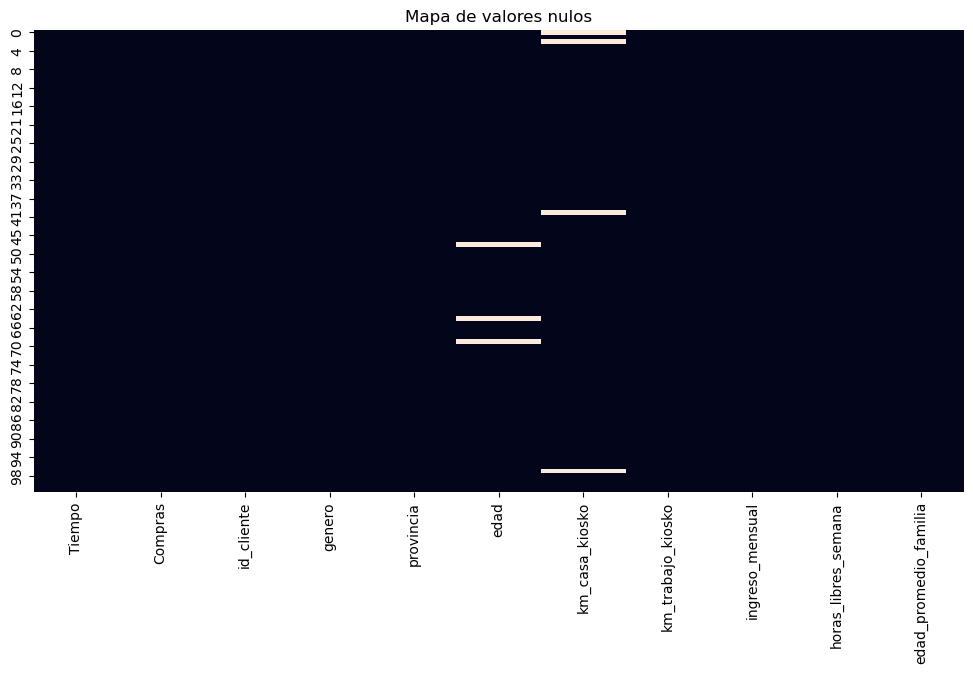

In [6]:
plt.figure(figsize=(12,6))
sns.heatmap(dfFinal.isnull(), cbar=False)
plt.title("Mapa de valores nulos")
plt.show()

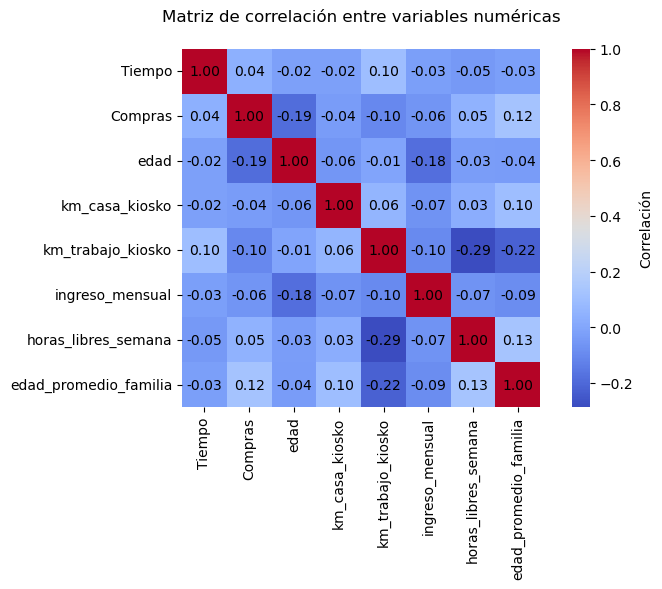

In [7]:

corr = dfFinal.corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True,
            cbar_kws={"label": "Correlación"},
            annot_kws={"size": 10, "color": "black"})
plt.title("Matriz de correlación entre variables numéricas", pad=20)
plt.tight_layout()
plt.show()


📊 Crear una diapositiva para presentarle a Don Jaime los principales resultados de tu análisis. Subirla al WebCampus.

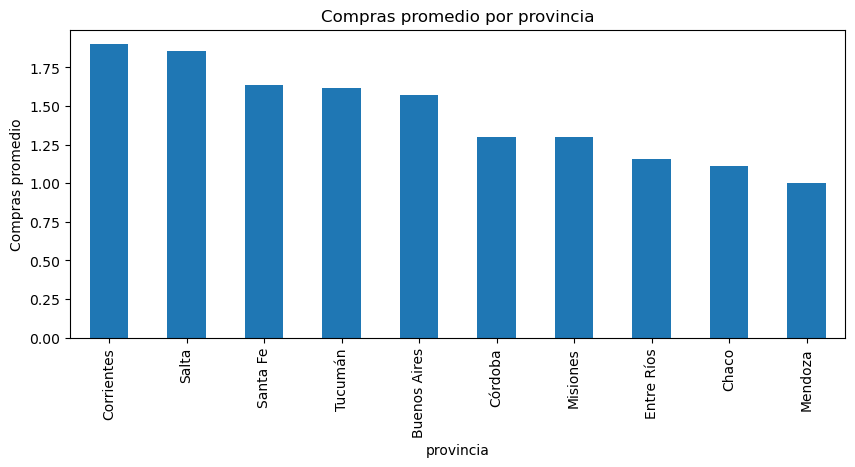

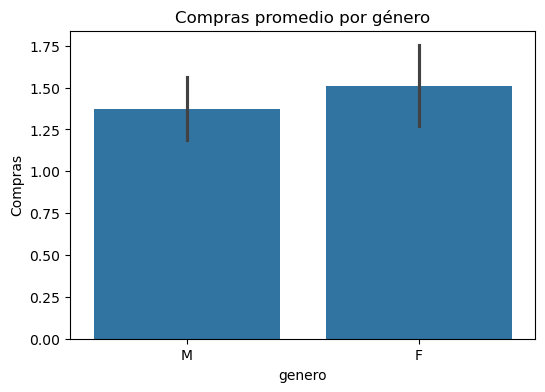

In [8]:
if {'provincia','Compras'}.issubset(dfFinal.columns):
    plt.figure(figsize=(10,4))
    (dfFinal.groupby('provincia')['Compras']
       .mean()
       .sort_values(ascending=False)
       .plot(kind='bar'))
    plt.title('Compras promedio por provincia')
    plt.ylabel('Compras promedio')
    plt.show()

if {'genero','Compras'}.issubset(dfFinal.columns):
    plt.figure(figsize=(6,4))
    sns.barplot(data=dfFinal, x='genero', y='Compras', estimator=np.mean, errorbar='se')
    plt.title('Compras promedio por género')
    plt.show()

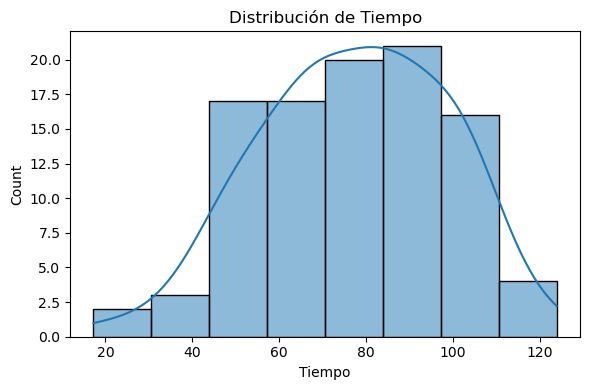

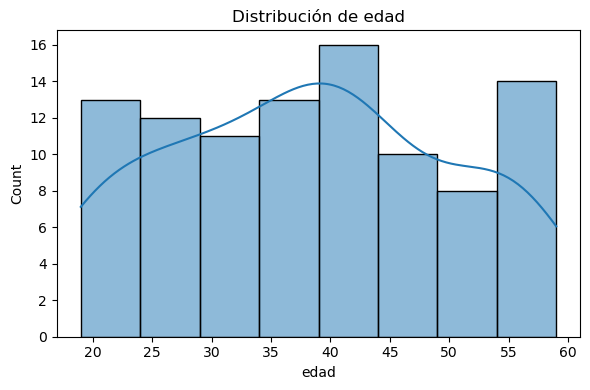

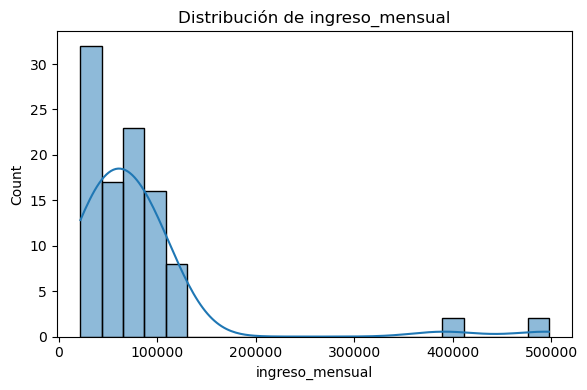

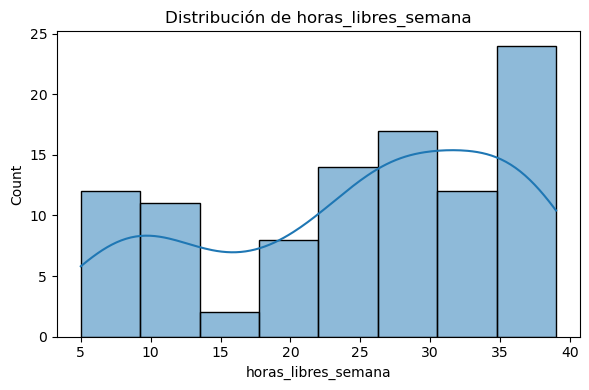

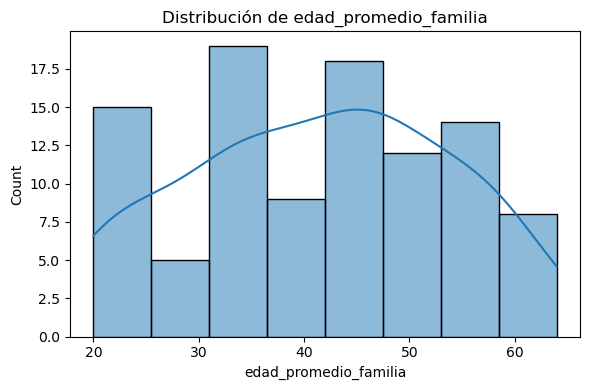

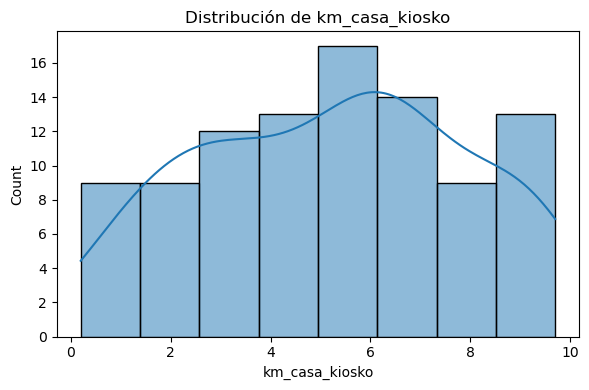

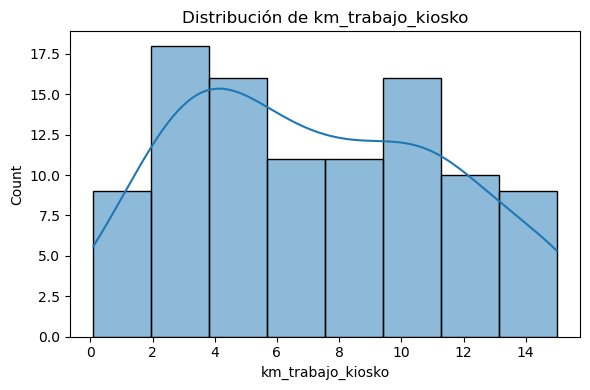

In [9]:
for c in ['Tiempo','edad','ingreso_mensual','horas_libres_semana',
          'edad_promedio_familia','km_casa_kiosko','km_trabajo_kiosko']:
    if c in dfFinal.columns:
        plt.figure(figsize=(6,4))
        sns.histplot(data=dfFinal, x=c, kde=True)
        plt.title(f'Distribución de {c}')
        plt.tight_layout(); plt.show()

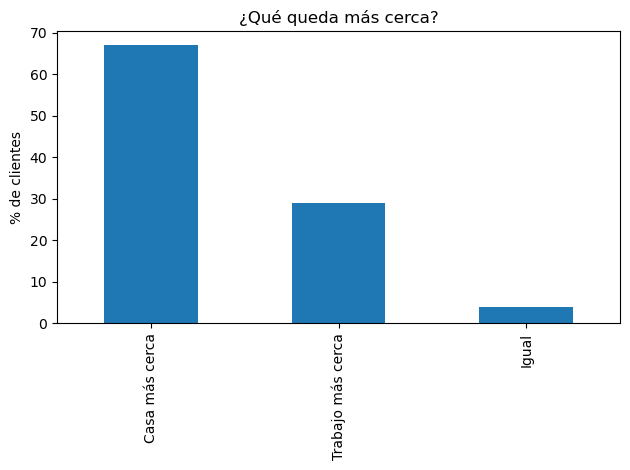

In [10]:
comp = np.where(dfFinal['km_casa_kiosko'] < dfFinal['km_trabajo_kiosko'], 'Casa más cerca',
        np.where(dfFinal['km_casa_kiosko'] > dfFinal['km_trabajo_kiosko'], 'Trabajo más cerca','Igual'))
import pandas as pd
(pd.Series(comp).value_counts(normalize=True)*100).reindex(['Casa más cerca','Trabajo más cerca','Igual']).plot(kind='bar')
plt.ylabel('% de clientes'); plt.title('¿Qué queda más cerca?'); plt.tight_layout(); plt.show()
